Setting up the 8x8 Parameter Grid...
Beginning sweep for N=1000 nodes. This may take some time...


Simulating: 100%|██████████| 64/64 [04:52<00:00,  4.56s/it]


Simulations complete! Generating Heatmap...


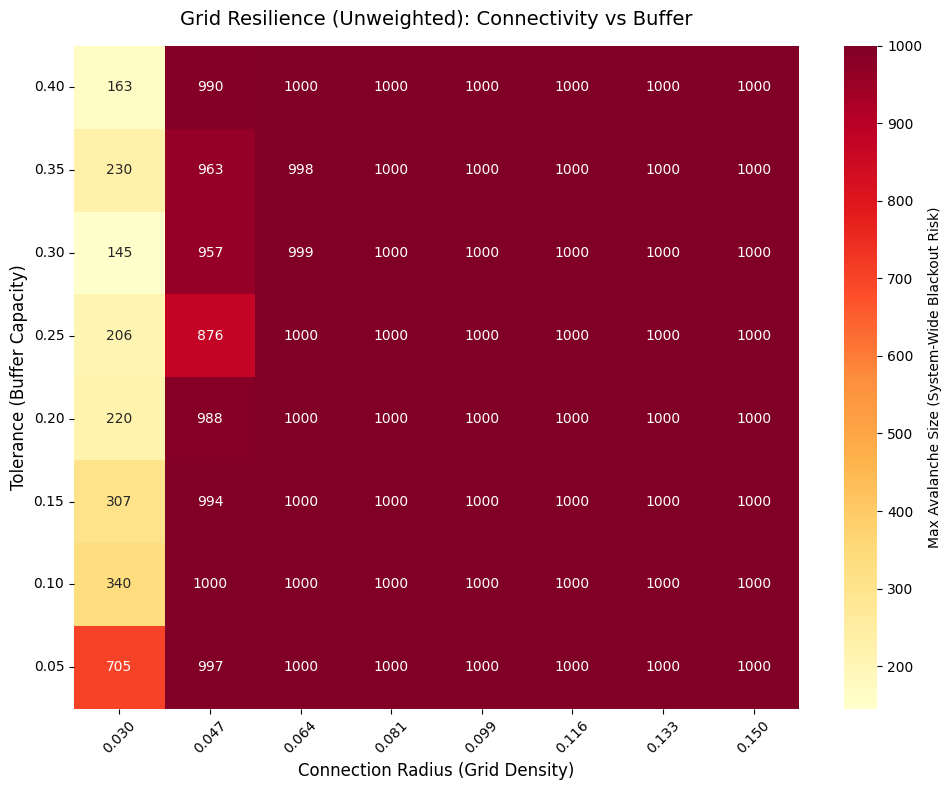

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # This provides the progress bar

# ==========================================
# 1. THE CORE SIMULATION FUNCTION (UNWEIGHTED)
# ==========================================
def run_simulation(radius, tolerance):
    """
    Runs a single unweighted power grid simulation and returns the Maximum Avalanche Size.
    """
    # Fixed Parameters based on your new baseline
    NUM_NODES = 1000
    NOISE = 0.8
    SIMULATION_STEPS = 2000  # TEST AT 2000 FIRST, THEN CHANGE TO 8000 FOR FINAL RUN

    # Build the standard Random Geometric Network (No weights)
    G = nx.random_geometric_graph(NUM_NODES, radius=radius)

    # Initialize Nodes
    for node in G.nodes():
        initial_load = np.random.uniform(0, 10)
        G.nodes[node]['load'] = initial_load
        G.nodes[node]['capacity'] = initial_load * (1 + tolerance)

    max_avalanche_size = 0

    # Run the Ticks
    for step in range(SIMULATION_STEPS):
        for node in G.nodes():
            G.nodes[node]['load'] += (NOISE / 10.0)
            G.nodes[node]['tripped'] = False

        current_avalanche = 0

        # The Cascade Loop
        while True:
            overloaded_nodes = [
                n for n, d in G.nodes(data=True)
                if d['load'] > d['capacity'] and not d['tripped']
            ]

            if not overloaded_nodes:
                break

            for node in overloaded_nodes:
                overload_amount = G.nodes[node]['load']

                # Node trips
                G.nodes[node]['load'] = 0
                G.nodes[node]['tripped'] = True
                current_avalanche += 1

                # Equal redistribution to active neighbors (No weights)
                active_neighbors = [nbr for nbr in G.neighbors(node) if not G.nodes[nbr]['tripped']]

                if len(active_neighbors) > 0:
                    spillover = overload_amount / len(active_neighbors)
                    for neighbor in active_neighbors:
                        G.nodes[neighbor]['load'] += spillover

        # Track the worst-case scenario for the heatmap
        if current_avalanche > max_avalanche_size:
            max_avalanche_size = current_avalanche

    return max_avalanche_size

# ==========================================
# 2. DEFINE THE PARAMETER SPACE
# ==========================================
print("Setting up the 8x8 Parameter Grid...")

# Adjusted radius sweep up to 0.15 to match your new base code
radius_values = np.linspace(0.03, 0.15, 8)
tolerance_values = np.linspace(0.05, 0.40, 8)

results_matrix = np.zeros((len(tolerance_values), len(radius_values)))
total_runs = len(radius_values) * len(tolerance_values)

# ==========================================
# 3. RUN THE AUTOMATED SWEEP
# ==========================================
print(f"Beginning sweep for N={run_simulation.__code__.co_consts[1]} nodes. This may take some time...")

with tqdm(total=total_runs, desc="Simulating") as pbar:
    for i, tol in enumerate(reversed(tolerance_values)):
        for j, rad in enumerate(radius_values):

            # Run the simulation
            max_size = run_simulation(rad, tol)
            results_matrix[i, j] = max_size

            pbar.update(1)

print("Simulations complete! Generating Heatmap...")

# ==========================================
# 4. PLOT THE HEATMAP
# ==========================================
plt.figure(figsize=(10, 8))

x_labels = [f"{r:.3f}" for r in radius_values]
y_labels = [f"{t:.2f}" for t in reversed(tolerance_values)]

ax = sns.heatmap(
    results_matrix,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    xticklabels=x_labels,
    yticklabels=y_labels,
    cbar_kws={'label': 'Max Avalanche Size (System-Wide Blackout Risk)'}
)

plt.title("Grid Resilience (Unweighted): Connectivity vs Buffer", fontsize=14, pad=15)
plt.xlabel("Connection Radius (Grid Density)", fontsize=12)
plt.ylabel("Tolerance (Buffer Capacity)", fontsize=12)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()